# СӨЖ 8: Сызықтық регрессия, Lasso, Ridge және Логистикалық регрессия

**Нұсқау:** Барлық `# TODO` белгіленген жерлерді толтырыңыз. Қиын тапсырмалардың жанында `# Нұсқау` берілген.

## Кітапханаларды жүктеу

Тапсырманы орындауға қажетті барлық Python кітапханалары осы ұяшықта импортталады.
Ұяшықты іске қосып, қате шықпағанын тексеріңіз.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, confusion_matrix,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

print("Барлық кітапханалар сәтті жүктелді.")

Барлық кітапханалар сәтті жүктелді.



# I бөлім: Сызықтық регрессия

**Мақсат:** California тұрғын үй деректері арқылы үй бағасын болжауды үйрену.
Сызықтық регрессияның математикалық негізін практикада қолдану.

## 1.1 Теориялық негіз

Сызықтық регрессия — нысана айнымалысы $y$ мен белгілер $\mathbf{x}$ арасындағы сызықтық байланысты модельдейді:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

Параметрлер жай квадраттар сомасын (RSS) минимизациялау арқылы табылады:

$$\text{RSS} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Аналитикалық шешім (қалыпты теңдеу):

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

**Бағалау метрикалары:**

- $\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$
- $R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$

$R^2 = 1$ — мінсіз болжам; $R^2 = 0$ — модель орташадан жақсы емес.

## 1.2 Деректерді жүктеу

California тұрғын үй деректері sklearn кітапханасынан тікелей жүктеледі.
Деректер жиынтығы 1990 жылғы санақ мәліметтеріне негізделген.

In [4]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df_house = housing.frame

print("Деректер өлшемі:", df_house.shape)
print()
print(df_house.head())

Деректер өлшемі: (20640, 9)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


## 1.3 Деректерді зерттеу (EDA)

Деректерге жалпы шолу жасаңыз: статистикалық сипаттама, жетіспейтін мәндер, нысана айнымалысының таралуы.

In [5]:
# TODO 1: df_house үшін .describe() әдісін шақырыңыз
# Нұсқау: df_house.describe()
# TODO
df_house.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
# TODO 2: Жетіспейтін мәндер бар ма? Тексеріңіз
# Нұсқау: .isnull().sum() әдісін пайдаланыңыз
# TODO
df_house.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


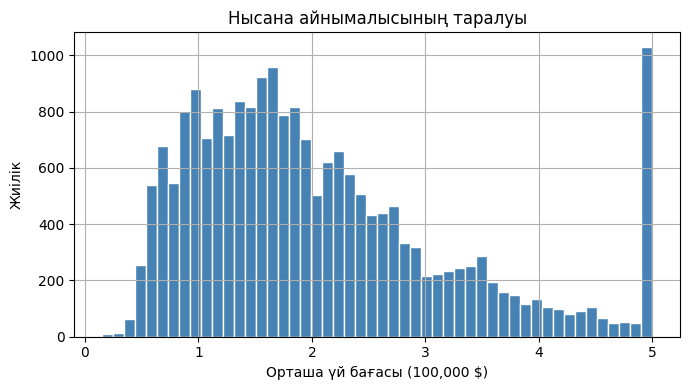

In [7]:
# Нысана айнымалысының гистограммасы (бұл код дайын)
plt.figure(figsize=(7, 4))
df_house['MedHouseVal'].hist(bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Орташа үй бағасы (100,000 $)')
plt.ylabel('Жиілік')
plt.title('Нысана айнымалысының таралуы')
plt.tight_layout()
plt.show()

## 1.4 Деректерді дайындау

Белгілер матрицасы мен нысана векторын бөлектеп, оқыту/тестілеу жиындарына бөліңіз.
Содан кейін белгілерді стандартты масштабтаумен нормализациялаңыз.

In [12]:
# TODO 3: X және y айнымалыларын анықтаңыз
# X — 'MedHouseVal' бағанынан басқа барлық бағандар
# y — 'MedHouseVal' бағаны
# Нұсқау: X = df_house.drop(columns=['MedHouseVal'])
X = df_house.drop(columns=['MedHouseVal'])
y = df_house['MedHouseVal']

print("X өлшемі:", X.shape)
print("y өлшемі:", y.shape)

X өлшемі: (20640, 8)
y өлшемі: (20640,)


In [17]:
# TODO 4: Деректерді оқыту (80%) және тест (20%) жиындарына бөліңіз
# Нұсқау: train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Оқыту жиыны:", X_train.shape)
print("Тест жиыны:", X_test.shape)

Оқыту жиыны: (16512, 8)
Тест жиыны: (4128, 8)


In [16]:
# TODO 5: StandardScaler арқылы белгілерді масштабтаңыз
# Нұсқау: scaler.fit(X_train) тек оқыту деректерінде орындалады,
#          содан кейін scaler.transform() екі жиынға да қолданылады
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.fit_transform(X_test)

## 1.5 Модельді оқыту және бағалау

In [22]:
# TODO 6: LinearRegression модельін жасап, оқытыңыз
# Нұсқау: model = LinearRegression(); model.fit(X_train_sc, y_train)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# TODO 7: Тест жиынында болжам жасаңыз
# Нұсқау: lr_model.predict(X_test_sc)
y_pred_lr = lr_model.predict(X_test_sc)

# Метрикаларды есептеу (дайын)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)
print(f"Сызықтық регрессия | MSE: {mse_lr:.4f} | R2: {r2_lr:.4f}")

Сызықтық регрессия | MSE: 1528.2655 | R2: -1165.2508


## 1.6 Нәтижені визуализациялау

Нақты мәндер мен болжамдар арасындағы байланысты шашырандыға (scatter plot) арқылы көрсетіңіз.

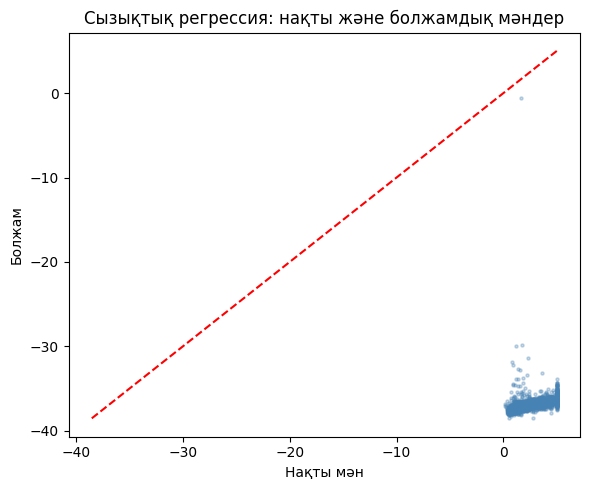

In [26]:
# TODO 8: Нақты мәндер (y_test) мен болжамдар (y_pred_lr) шашырандысын салыңыз
# x осі — y_test, y осі — y_pred_lr
# Нұсқау: plt.scatter(y_test, y_pred_lr, alpha=0.3)
# Идеал болжам үшін қызыл диагональ сызық қосыңыз: plt.plot([min,max],[min,max],'r--')

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_lr, alpha =0.3, color = 'steelblue', s=5)
# TODO
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='идеал болжам')

plt.xlabel('Нақты мән')
plt.ylabel('Болжам')
plt.title('Сызықтық регрессия: нақты және болжамдық мәндер')
plt.tight_layout()
plt.show()



# II бөлім: Ridge және Lasso регрессия

**Мақсат:** Реттелген регрессия модельдерін түсіну және сызықтық регрессиямен салыстыру.
Реттеу параметрі $\alpha$ моделдің мінез-құлқына қалай әсер ететінін зерттеу.

## 2.1 Теориялық негіз

Реттелген регрессия — RSS-ке жаза мүшесін қосу арқылы модельдің артық оқуын (overfitting) азайтады.

**Ridge (L2 реттеу):**

$$\min_{\boldsymbol{\beta}} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$

Ridge коэффициенттерді нөлге жақындатады, бірақ дәл нөлге айналдырмайды.

**Lasso (L1 реттеу):**

$$\min_{\boldsymbol{\beta}} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j|$$

Lasso кейбір коэффициенттерді дәл нөлге айналдырады — автоматты белгілер таңдауы жүреді.

$\alpha = 0$ болса — қарапайым сызықтық регрессия; $\alpha \to \infty$ болса — барлық коэффициенттер нөлге ұмтылады.

## 2.2 Ridge және Lasso модельдерін оқыту

Бір бөлімде жасалған масштабталған деректер (X_train_sc, X_test_sc) пайдаланылады.

In [27]:
# TODO 9: Ridge модельін жасап, оқытыңыз (alpha=1.0)
# Нұсқау: Ridge(alpha=1.0)
ridge_model =  Ridge(alpha=1.0)
ridge_model.fit(X_train_sc, y_train)

y_pred_ridge = ridge_model.predict(X_test_sc)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge  = r2_score(y_test, y_pred_ridge)
print(f"Ridge | MSE: {mse_ridge:.4f} | R2: {r2_ridge:.4f}")

Ridge | MSE: 0.5388 | R2: 0.5888


In [29]:
# TODO 10: Lasso модельін жасап, оқытыңыз (alpha=0.01)
# Нұсқау: Lasso(alpha=0.01, max_iter=5000)
lasso_model =  Lasso(alpha=0.01, max_iter=5000)
lasso_model.fit(X_train_sc, y_train)
# TODO — fit

y_pred_lasso = lasso_model.predict(X_test_sc)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso  = r2_score(y_test, y_pred_lasso)
print(f"Lasso | MSE: {mse_lasso:.4f} | R2: {r2_lasso:.4f}")

Lasso | MSE: 0.5399 | R2: 0.5880


## 2.3 Коэффициенттерді салыстыру

Үш модельдің коэффициенттерін бағандық диаграммада салыстырыңыз.
Lasso қандай белгілерді нөлге айналдырғанын байқаңыз.

In [30]:
feature_names = X.columns.tolist()

coef_df = pd.DataFrame({
    'Белгі':        feature_names,
    'Сызықтық':    lr_model.coef_,
    'Ridge':        ridge_model.coef_,
    'Lasso':        lasso_model.coef_
})

print(coef_df.to_string(index=False))

     Белгі  Сызықтық     Ridge     Lasso
    MedInc  0.448675  0.854327  0.800957
  HouseAge  0.009724  0.122624  0.127087
  AveRooms -0.123323 -0.294210 -0.162759
 AveBedrms  0.783145  0.339008  0.206207
Population -0.000002 -0.002282 -0.000000
  AveOccup -0.003526 -0.040833 -0.030602
  Latitude -0.419792 -0.896168 -0.790113
 Longitude -0.433708 -0.869071 -0.755674


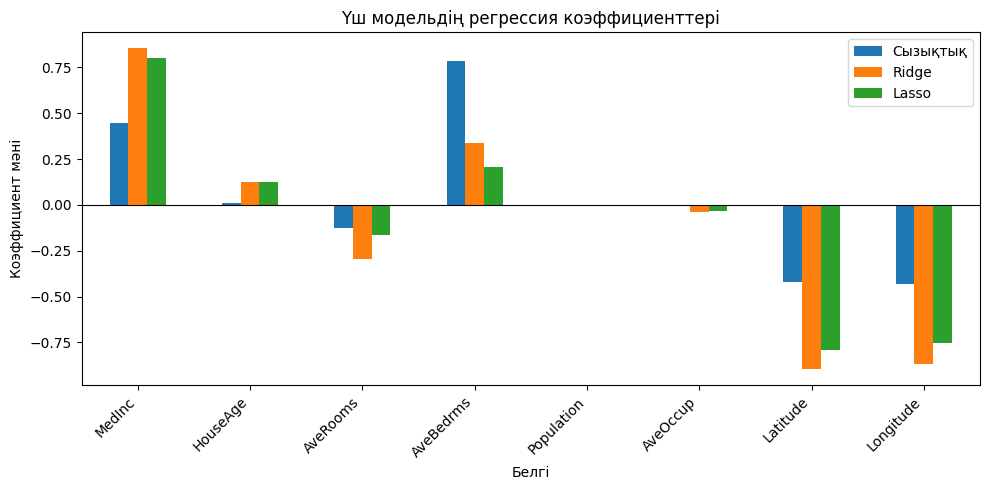

In [31]:
# TODO 11: coef_df негізінде бағандық диаграмма салыңыз
# x осі — белгі атаулары, y осі — коэффициент мәндері
# Үш модельді бір диаграммада салыстырыңыз
# Нұсқау: coef_df.plot(x='Белгі', kind='bar', figsize=(10,5))

# TODO
coef_df.plot(x='Белгі', kind='bar', figsize=(10, 5))
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Үш модельдің регрессия коэффициенттері')
plt.ylabel('Коэффициент мәні')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2.4 Alpha параметрінің әсері

$\alpha$ мәрінің өзгеруіне байланысты Ridge коэффициенттерінің қалай өзгеретінін байқаңыз.

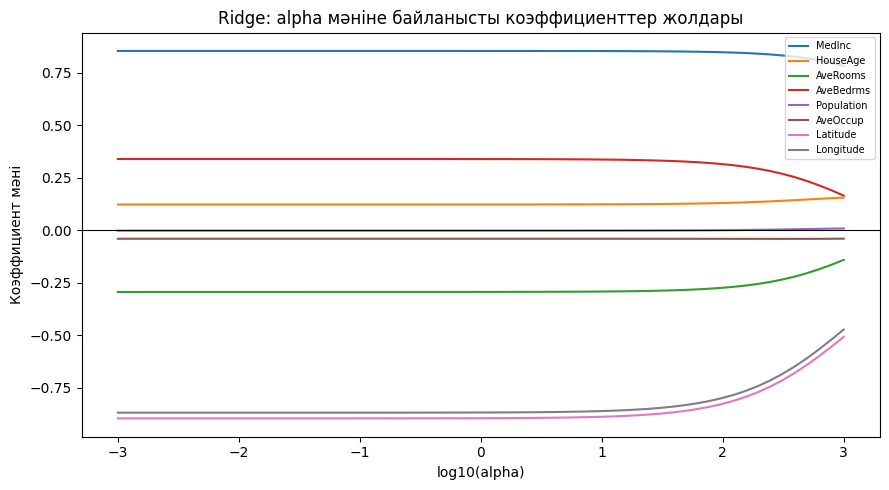

In [32]:
alphas = np.logspace(-3, 3, 60)
coef_paths = []

for a in alphas:
    m = Ridge(alpha=a)
    m.fit(X_train_sc, y_train)
    coef_paths.append(m.coef_)

coef_paths = np.array(coef_paths)

plt.figure(figsize=(9, 5))
for j in range(coef_paths.shape[1]):
    plt.plot(np.log10(alphas), coef_paths[:, j], label=feature_names[j])
plt.xlabel('log10(alpha)')
plt.ylabel('Коэффициент мәні')
plt.title('Ridge: alpha мәніне байланысты коэффициенттер жолдары')
plt.legend(fontsize=7, loc='upper right')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

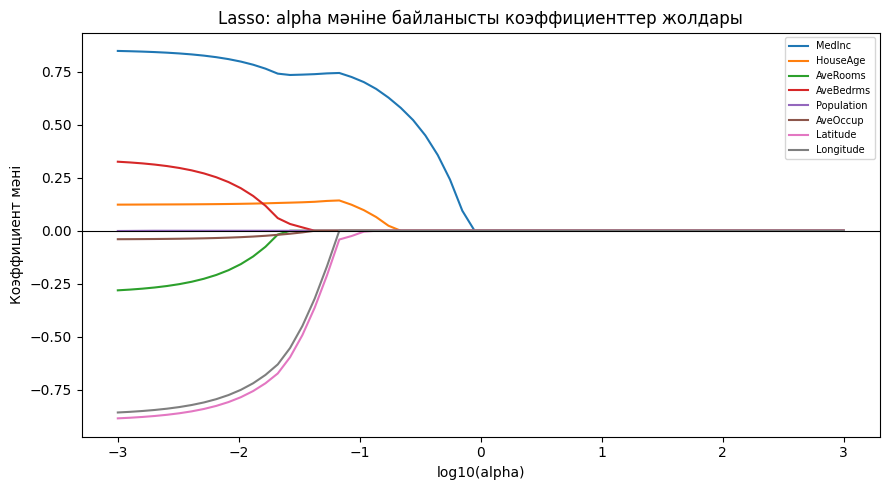

In [39]:
# TODO 12: Жоғарыдағы кодты Lasso үшін қайталаңыз
# Нұсқау: Ridge орнына Lasso(alpha=a, max_iter=3000) қолданыңыз
# Lasso графигі қандай ерекшелікке ие болады? (кейбір коэффициенттер нөлге дейін жетеді)
lasso_coef_paths = []
for a in alphas:
    m = Lasso(alpha=a, max_iter=3000)
    m.fit(X_train_sc, y_train)
    lasso_coef_paths.append(m.coef_)

lasso_coef_paths = np.array(lasso_coef_paths)

plt.figure(figsize=(9, 5))
for j in range(lasso_coef_paths.shape[1]):
    plt.plot(np.log10(alphas), lasso_coef_paths[:, j], label=feature_names[j])
plt.xlabel('log10(alpha)')
plt.ylabel('Коэффициент мәні')
plt.title('Lasso: alpha мәніне байланысты коэффициенттер жолдары')
plt.legend(fontsize=7, loc='upper right')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


# TODO




# III бөлім: Логистикалық регрессия

**Мақсат:** Банктік клиенттер деректерінде churn (кетіп қалу) жағдайын болжауды үйрену.
Логистикалық регрессияны екілік жіктеу есебіне қолдану.

## 3.1 Теориялық негіз

Логистикалық регрессия — екілік жіктеу үшін қолданылатын модель. Нысана: $y \in \{0, 1\}$.

Сигмоид функциясы арқылы ықтималдық есептеледі:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{x}^\top \boldsymbol{\beta}) = \frac{1}{1 + e^{-\mathbf{x}^\top \boldsymbol{\beta}}}$$

Параметрлер логарифмдік ортақтылықты (log-likelihood) максимизациялау арқылы табылады:

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n}\left[y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i)\right]$$

**Бағалау метрикалары:**

- **Дәлдік (Accuracy):** дұрыс жіктелген үлгілер үлесі
- **Шатастыру матрицасы:** TP, TN, FP, FN мәндері
- **Precision / Recall / F1:** теңгерімсіз сыныптарда маңызды

## 3.2 Deректерді жүктеу

Bank Churn деректері GitHub-тен жүктеледі.
Клиент банктен кетіп қалды ма (Exited = 1) немесе қалды ма (Exited = 0) — міне, болжайтын нысанамыз.

In [40]:
url_churn = (
    "https://raw.githubusercontent.com/dsrscientist/"
    "dataset1/master/telecom_churn.csv"
)

# Жүктеу мүмкін болмаса sklearn деректерін пайдаланыңыз
try:
    df_churn = pd.read_csv(url_churn)
    print("GitHub-тен жүктелді.")
except Exception:
    # Балама: sklearn breast_cancer деректері
    from sklearn.datasets import load_breast_cancer
    bc = load_breast_cancer(as_frame=True)
    df_churn = bc.frame.rename(columns={'target': 'Churn'})
    df_churn['Churn'] = 1 - df_churn['Churn']   # 1 = malignant
    print("Балама деректер жүктелді (breast_cancer).")

print("Өлшем:", df_churn.shape)
print(df_churn.head(3))

Балама деректер жүктелді (breast_cancer).
Өлшем: (569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   
2        19.69         21.25           130.0     1203.0          0.10960   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0                 0.07871  ...          17.33            184.6      2019.0   
1                 0.05667  ...          23.41            158.8      1956.0   
2                 0.05999  ...          25.53            152.5      1709.0   

   worst smoothness  w

In [41]:
# Churn бағанын табу (деректер көзіне байланысты атауы өзгеруі мүмкін)
# Дайын код: деректерді стандартты форматқа келтіреміз

numeric_df = df_churn.select_dtypes(include=[np.number])

# Нысана бағанын анықтаймыз
target_candidates = [c for c in numeric_df.columns
                     if numeric_df[c].nunique() == 2]
if not target_candidates:
    raise ValueError("Екілік нысана бағаны табылмады.")

target_col = target_candidates[-1]
print(f"Нысана бағаны: '{target_col}'")
print(numeric_df[target_col].value_counts())

Нысана бағаны: 'Churn'
Churn
0    357
1    212
Name: count, dtype: int64


## 3.3 Деректерді зерттеу

In [44]:
# TODO 13: Нысана сыныптарының үлесін (value_counts) шығарыңыз
# Деректер теңгерімді ме?
# TODO
print("Сынып саны:")
print(numeric_df[target_col].value_counts())
print()
print("Сынып үлесі (%)")
print((numeric_df[target_col].value_counts(normalize=True) * 100).round(2))


Сынып саны:
Churn
0    357
1    212
Name: count, dtype: int64

Сынып үлесі (%)
Churn
0    62.74
1    37.26
Name: proportion, dtype: float64


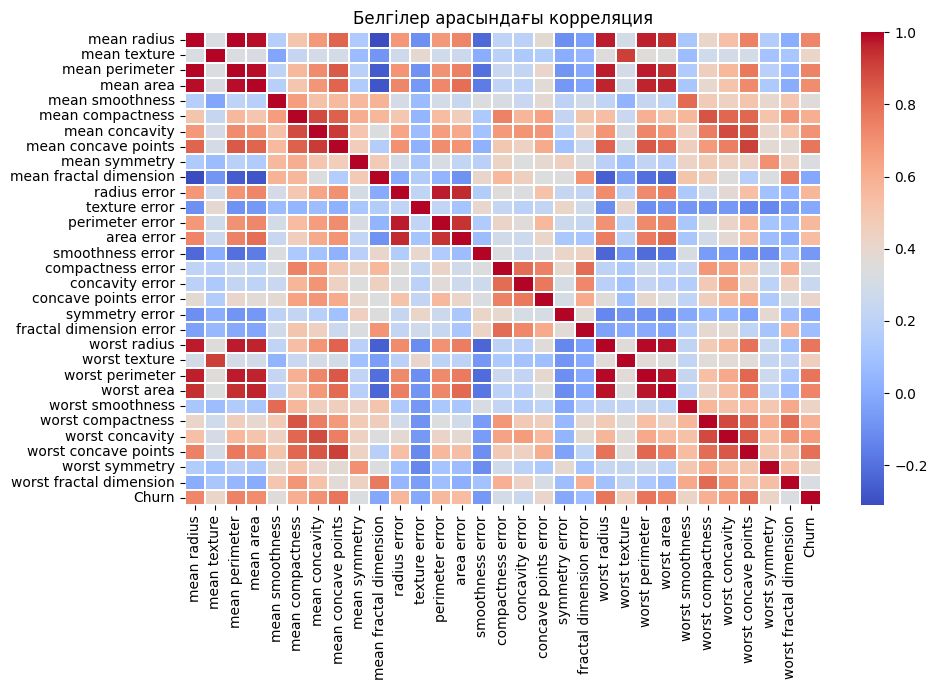

In [45]:
# Корреляция жылу картасы (дайын)
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm',
            linewidths=0.3, fmt='.1f')
plt.title('Белгілер арасындағы корреляция')
plt.tight_layout()
plt.show()

## 3.4 Деректерді дайындау

In [46]:
# TODO 14: X және y айнымалыларын анықтаңыз
# X — нысана бағанынан басқа барлық сандық бағандар
# y — нысана бағаны (target_col)

X_c = numeric_df.drop(columns=[target_col])
y_c = numeric_df[target_col]


print("X өлшемі:", X_c.shape)
print("y өлшемі:", y_c.shape)

X өлшемі: (569, 30)
y өлшемі: (569,)


In [48]:
# TODO 15: Деректерді оқыту (75%) және тест (25%) жиындарына бөліңіз
# stratify=y_c параметрін қосыңыз — сыныптар үлесін сақтайды
# Нұсқау: train_test_split(X_c, y_c, test_size=0.25, random_state=42, stratify=y_c)

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_c, y_c, test_size=0.25, random_state=42, stratify=y_c
)

scaler_c = StandardScaler()
X_tr_c_sc = scaler_c.fit_transform(X_tr_c)
X_te_c_sc = scaler_c.transform(X_te_c)

print("Оқыту жиыны:", X_tr_c.shape)
print("Тест жиыны:", X_te_c.shape)

Оқыту жиыны: (426, 30)
Тест жиыны: (143, 30)


## 3.5 Модельді оқыту

In [49]:
# TODO 16: LogisticRegression модельін жасап, оқытыңыз
# Нұсқау: LogisticRegression(max_iter=1000, random_state=42)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_tr_c_sc, y_tr_c)

y_pred_log = log_model.predict(X_te_c_sc)
acc = accuracy_score(y_te_c, y_pred_log)
print(f"Дәлдік (Accuracy): {acc:.4f}")

Дәлдік (Accuracy): 0.9650


## 3.6 Модельді бағалау

Шатастыру матрицасы және жіктеу есебін талдаңыз.

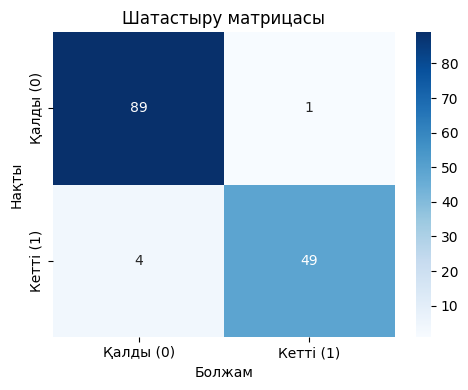

In [53]:
# Шатастыру матрицасы (дайын)
cm = confusion_matrix(y_te_c, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Қалды (0)', 'Кетті (1)'],
            yticklabels=['Қалды (0)', 'Кетті (1)'])
plt.xlabel('Болжам')
plt.ylabel('Нақты')
plt.title('Шатастыру матрицасы')
plt.tight_layout()
plt.show()

In [52]:
# TODO 17: classification_report шығарыңыз
# Нұсқау: print(classification_report(y_te_c, y_pred_log))
# TODO
print(classification_report(y_te_c, y_pred_log))


              precision    recall  f1-score   support

           0       0.96      0.99      0.97        90
           1       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



## 3.7 Болжамдық ықтималдықтар

Логистикалық регрессия 0/1 болжамынан бөлек ықтималдықтар да береді.
Ықтималдықтардың таралуын зерттеңіз.

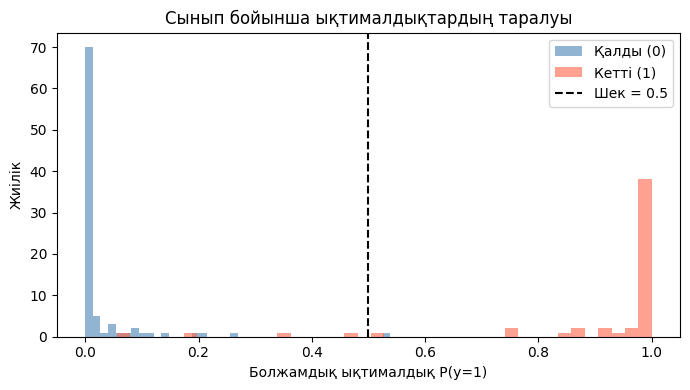

In [54]:
# TODO 18: predict_proba арқылы тест жиынының ықтималдықтарын алыңыз
# Нұсқау: log_model.predict_proba(X_te_c_sc)[:, 1]  — 1-сынып ықтималдығы

y_prob = log_model.predict_proba(X_te_c_sc)[:, 1]


plt.figure(figsize=(7, 4))
plt.hist(y_prob[y_te_c == 0], bins=40, alpha=0.6, label='Қалды (0)', color='steelblue')
plt.hist(y_prob[y_te_c == 1], bins=40, alpha=0.6, label='Кетті (1)', color='tomato')
plt.axvline(0.5, color='black', linestyle='--', label='Шек = 0.5')
plt.xlabel('Болжамдық ықтималдық P(y=1)')
plt.ylabel('Жиілік')
plt.title('Сынып бойынша ықтималдықтардың таралуы')
plt.legend()
plt.tight_layout()
plt.show()



# IV бөлім: Қорытынды сұрақтар

**Мақсат:** Тапсырманы орындаған соң теориялық түсінігіңізді тексеріңіз.
Төмендегі ұяшықтарға жауаптарыңызды жазыңыз.

## 4.1 Сұрақтар

**1.** Сызықтық регрессия коэффициенттерін оқыту алдында белгілерді масштабтаудың қажеті бар ма? Неліктен?

**2.** Ridge және Lasso регрессиясының айырмашылығы неде? Қайсысы белгілер таңдауын орындайды?

**3.** $\alpha$ параметрі үлкейген сайын Ridge модельінің коэффициенттері қалай өзгереді?

**4.** Логистикалық регрессия нақты регрессия ма, жоқ әлде жіктеу моделі ме? Жауабыңызды дәлелдеңіз.

**5.** Шатастыру матрицасындағы FP (жалған оң) және FN (жалған теріс) қателер банктік churn контексінде қандай маңызды?

## 4.3 Модельдер нәтижелерін жинақтайтын кесте

In [55]:
# TODO 19: Үш регрессия моделінің MSE және R2 мәндерін кестеге жинаңыз
# Нұсқау: pd.DataFrame арқылы кесте жасаңыз

summary = pd.DataFrame({
    'Модель': ['Сызықтық регрессия', 'Ridge', 'Lasso'],
    'MSE':    [mse_lr, mse_ridge, mse_lasso],
    'R2':     [r2_lr,  r2_ridge,  r2_lasso]
})

# TODO 20: summary кестесін 'R2' бойынша кему тәртібінде сұрыптаңыз
# Нұсқау: .sort_values('R2', ascending=False)
# TODO

summary = summary.sort_values('R2', ascending=False)

print(summary)

               Модель          MSE           R2
1               Ridge     0.538850     0.588793
2               Lasso     0.539918     0.587978
0  Сызықтық регрессия  1528.265547 -1165.250821
